In [1]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

/tmp/ipykernel_12574/4076898081.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)

In [3]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",") # El separador es "," porque en el archivo .csv los valores están separados por coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar

In [4]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [5]:
# ================================================================================================================== #
# 4. ONE-HOT ENCODING (A las variables categóricas aplícales One-Hot Encoding, 
# y a las numéricas déjalas como están) #
# ================================================================================================================== #
 
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
])

In [6]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor

ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', StandardScaler(),
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [7]:
# ============================= #
# 5. MOSTRAR LA BASE CODIFICADA #
# ============================= #
 
X = df[cat_cols + features]
X_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_encoded_df = pd.DataFrame.sparse.from_spmatrix(X_encoded, columns=feature_names)
X_encoded_df.sample(20)

,cat__job_title_Backend Developer,cat__job_title_Business Analyst,cat__job_title_Cloud Engineer,cat__job_title_Cybersecurity Analyst,cat__job_title_Data Analyst,cat__job_title_Data Scientist,cat__job_title_DevOps Engineer,cat__job_title_Frontend Developer,cat__job_title_Machine Learning Engineer,cat__job_title_Product Manager,cat__job_title_Software Engineer,cat__education_level_Diploma,cat__education_level_High School,cat__education_level_Master,cat__education_level_PhD,cat__industry_Education,cat__industry_Finance,cat__industry_Government,cat__industry_Healthcare,cat__industry_Manufacturing,cat__industry_Media,cat__industry_Retail,cat__industry_Technology,cat__industry_Telecom,cat__company_size_Large,cat__company_size_Medium,cat__company_size_Small,cat__company_size_Startup,cat__location_Canada,cat__location_Germany,cat__location_India,cat__location_Netherlands,cat__location_Remote,cat__location_Singapore,cat__location_Sweden,cat__location_UK,cat__location_USA,cat__remote_work_No,cat__remote_work_Yes,num__experience_years,num__skills_count,num__certifications
139526,0,0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0.82411,1.095434,-1.460281
66612,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.495894,-0.91213,0.883737
12605,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,1.0,0,0,0,0,0,1.0,0,0,0,0,1.0,-0.000892,-0.182106,-1.460281
171225,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0.98911,0.912928,1.469741
24525,0,0,0,0,0,0,0,0,0,1.0,0,0,0,1.0,0,0,0,0,0,0,0,0,1.0,0,0,1.0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0,-0.000892,-0.547118,-0.288272
2740,0,0,0,0,0,1.0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,1.484112,-0.182106,-0.288272
175957,0,0,0,0,0,0,1.0,0,0,0,0,0,0,1.0,0,0,0,1.0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,1.0,-0.660894,1.642952,0.883737
202713,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1.0,0,0,1.0,0,0,0,0,0,0,0,0,1.0,0.659109,0.547917,0.883737
73885,0,0,0,0,0,0,0,0,0,1.0,0,0,0,1.0,0,0,1.0,0,0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0.164108,1.095434,0.297732
53194,0,0,0,0,0,1.0,0,0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0,0,0,0,0,0,0,0,0,0,1.0,0,1.0,0,-0.495894,1.095434,-0.288272


In [8]:
# ============================================= #
# 6. MOSTRAR LAS COLUMNAS DE LA BASE CODIFICADA #
# ============================================= #
X_encoded_df.columns.tolist()

['cat__job_title_Backend Developer',
 'cat__job_title_Business Analyst',
 'cat__job_title_Cloud Engineer',
 'cat__job_title_Cybersecurity Analyst',
 'cat__job_title_Data Analyst',
 'cat__job_title_Data Scientist',
 'cat__job_title_DevOps Engineer',
 'cat__job_title_Frontend Developer',
 'cat__job_title_Machine Learning Engineer',
 'cat__job_title_Product Manager',
 'cat__job_title_Software Engineer',
 'cat__education_level_Diploma',
 'cat__education_level_High School',
 'cat__education_level_Master',
 'cat__education_level_PhD',
 'cat__industry_Education',
 'cat__industry_Finance',
 'cat__industry_Government',
 'cat__industry_Healthcare',
 'cat__industry_Manufacturing',
 'cat__industry_Media',
 'cat__industry_Retail',
 'cat__industry_Technology',
 'cat__industry_Telecom',
 'cat__company_size_Large',
 'cat__company_size_Medium',
 'cat__company_size_Small',
 'cat__company_size_Startup',
 'cat__location_Canada',
 'cat__location_Germany',
 'cat__location_India',
 'cat__location_Netherlands

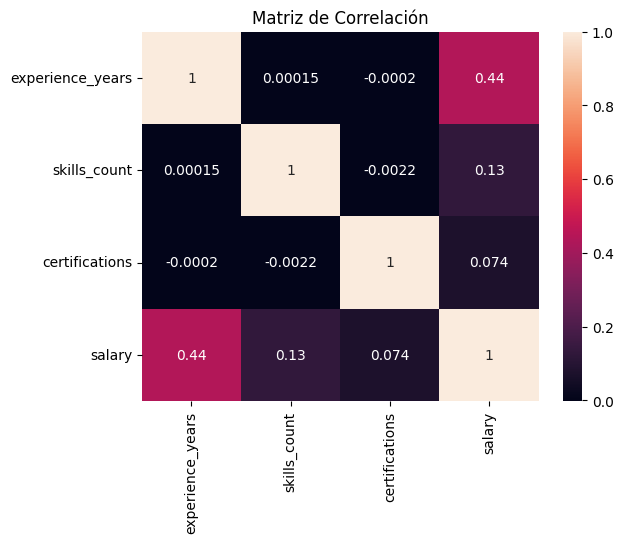

In [9]:
# ===================================================== #
# 7. ANÁLISIS DE CORRELACIÓN (Solo variables numéricas) #
# ===================================================== #

corr = df[features + [target]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Matriz de Correlación")
plt.show()

In [10]:
# ========================= #
# 8. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols] 
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:
# ====================== #
# 9. MODELO DE REGRESIÓN #
# ====================== #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('regressor', LinearRegression())])

In [12]:
# ============== #
# 10. EVALUACIÓN #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)

MAE: 5469.155709565889
RMSE: 7170.52842805288
MAPE: 0.04161551721436608
MAPE(%): 4.161551721436608
R2: 0.963104299907884


In [13]:
# ======================================== #
# 10.1. DATAFRAME CON RESULTADOS Y ERRORES # 
# ======================================== #

# Asegurar formatos
X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

# Construir DataFrame final
df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df

df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)

,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
50373,6,8,4,Cloud Engineer,PhD,Media,Startup,Australia,No,130103,134011.120820,-3908.120820,3908.120820
21717,12,19,2,Machine Learning Engineer,PhD,Technology,Enterprise,Canada,No,261681,237517.890672,24163.109328,24163.109328
66058,10,16,2,AI Engineer,Bachelor,Healthcare,Small,Netherlands,Hybrid,150515,155385.107303,-4870.107303,4870.107303
63917,3,9,5,Data Scientist,PhD,Manufacturing,Medium,Sweden,No,132489,136951.151309,-4462.151309,4462.151309
33405,19,6,2,Machine Learning Engineer,High School,Education,Large,UK,Hybrid,194859,191903.055081,2955.944919,2955.944919
65873,18,13,5,Backend Developer,Master,Manufacturing,Startup,Remote,Yes,155204,153976.899235,1227.100765,1227.100765
57489,15,13,5,Cloud Engineer,PhD,Telecom,Startup,Canada,No,189970,192041.492318,-2071.492318,2071.492318
65383,15,9,5,Cybersecurity Analyst,PhD,Healthcare,Small,Singapore,Yes,163151,169927.591164,-6776.591164,6776.591164
45901,0,18,1,Business Analyst,High School,Manufacturing,Small,Australia,Hybrid,76385,66073.078046,10311.921954,10311.921954
43243,16,6,4,Data Analyst,Bachelor,Education,Large,UK,No,151645,154682.840679,-3037.840679,3037.840679


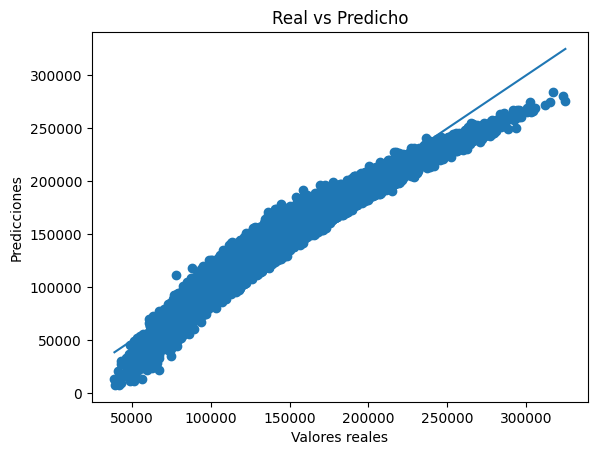

In [14]:
# ====================== #
# 10.2. REAL VS PREDICHO #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")

# Línea ideal
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)

plt.show()

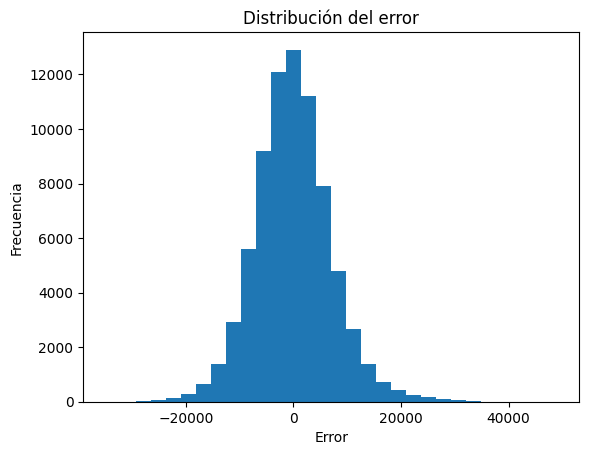

In [15]:
# ============================= #
# 10.3. DISTRIBUCIÓN DE ERRORES #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()